# Example 12b: DD-PINN vs PIRNN on the Same System

Examples [12](12_pinn.ipynb) and [12a](12a_ddpinn_surrogate.ipynb) introduced two
different ways to train a model from a system's governing equations:

- **PIRNN** (example 12) — a *discrete-time* physics-informed RNN. It enforces the ODE
  through a finite-difference residual on its sampled outputs, anchors the initial
  condition with a soft loss term, and learns an encoder that maps a measured window to
  the RNN's hidden state.
- **DD-PINN** (example 12a) — a *continuous-time* surrogate with a damped-sinusoid ansatz.
  The initial condition is exact by construction, the time-derivative is closed-form (so
  the physics residual uses no finite differences), and it trains on collocation points
  alone.

Both can be trained on **physics only**, and both end up as free-running simulators: give
them an initial state and a control sequence, and they predict the trajectory. This
example puts them head-to-head on the **same mass-spring-damper system** from example 12
and measures how accurately each reproduces a held-out measured trajectory.

## Prerequisites

- [Example 12: Physics-Informed Neural Networks (PINN)](12_pinn.ipynb) — the PIRNN setup
- [Example 12a: Physics-Only Surrogates with the DD-PINN](12a_ddpinn_surrogate.ipynb) — the DD-PINN

## Setup

In [1]:
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F

from tsfast.pinn import CollocationLoss, DampedAnsatzPINN, PhysicsLoss, SurrogatePINNLearner
from tsfast.pinn.differentiation import diff1_forward
from tsfast.pinn.signals import generate_excitation_signals
from tsfast.pinn.pirnn import PIRNNLearner
from tsfast.tsdata import create_dls
from tsfast.training import fun_rmse, zero_loss

torch.manual_seed(0)

## The system and its governing equation

The same forced mass-spring-damper as example 12, with state `[x, v]` (position,
velocity), control `u` (force), and `m·a + c·v + k·x = u`. The bundled dataset samples it
at 100 Hz; every trajectory starts from rest.

In [2]:
MASS, SPRING_CONSTANT, DAMPING_COEFFICIENT, DT = 1.0, 1.0, 0.1, 0.01


def _find_project_root(marker: str = "test_data") -> Path:
    try:
        start = Path(__file__).resolve().parent
    except NameError:
        start = Path(".").resolve()
    p = start
    while p != p.parent:
        if (p / marker).is_dir():
            return p
        p = p.parent
    raise FileNotFoundError(f"Could not find '{marker}' directory above {start}")


DATA = _find_project_root() / "test_data" / "pinn"

We will judge both models on the **held-out test trajectory** (a 1.5 Hz sine input that
neither model is trained on), comparing the predicted `x` and `v` against the measured
response.

In [3]:
with h5py.File(DATA / "test" / "trajectory_sine_1.5hz.h5", "r") as h:
    u_test, x_test, v_test = h["u"][:], h["x"][:], h["v"][:]
N = len(u_test)
INIT_SZ = 10  # warm-up window the PIRNN needs; we score both models from here on

## Two encodings of the same ODE

The two regimes ask for the physics in different shapes, but it is the *same* equation.

The **DD-PINN** wants the ODE as an explicit first-order residual in physical units. We
rewrite `m·a + c·v + k·x = u` as the first-order system `ẋ = v`, `v̇ = (u − c·v − k·x)/m`
and return the stacked residual:

In [4]:
def ddpinn_residual(x_phys, cond_phys, dxdt_phys):
    x, v = x_phys[..., 0:1], x_phys[..., 1:2]
    dx, dv = dxdt_phys[..., 0:1], dxdt_phys[..., 1:2]
    u = cond_phys[..., 0:1]
    res = torch.cat(
        [dx - v, dv - (u - DAMPING_COEFFICIENT * v - SPRING_CONSTANT * x) / MASS], dim=-1
    )
    return F.mse_loss(res, torch.zeros_like(res))

The **PIRNN** wants a loss that scores its sampled outputs: the ODE residual via a
finite-difference acceleration, a velocity/`dx/dt` consistency term, and (when reference
data is available) an initial-condition anchor. This is exactly `spring_damper_physics`
from example 12.

In [5]:
def spring_damper_physics(u, y_pred, y_ref):
    x, v = y_pred[:, :, 0], y_pred[:, :, 1]
    u_force = u[:, :, 0]
    a = diff1_forward(v, DT)
    dx_dt = diff1_forward(x, DT)
    loss = {
        "physics": ((MASS * a + DAMPING_COEFFICIENT * v + SPRING_CONSTANT * x - u_force) ** 2).mean(),
        "derivative": ((v - dx_dt) ** 2).mean(),
    }
    if y_ref is not None:
        loss["initial"] = ((x[:, :INIT_SZ] - y_ref[:, :INIT_SZ, 0]) ** 2).mean()
    return loss

## Train the DD-PINN (physics only)

Continuous-time surrogate, no measured data. We give it the physical ranges the test
trajectory lives in (a little wider than the data — the printed measured min/max
below verifies that every test sample falls inside the box, so the surrogate
interpolates rather than extrapolates), a uniform collocation sampler in
normalized `[-1, 1]` coordinates with row layout `[x, v, u, t]`, and a training horizon
`t_max = 0.1 s`. The horizon is ten sample steps wide on purpose: it keeps the normalized
time-derivatives well scaled, while the rollout below still steps at the dataset's
`dt = 0.01 s`.

In [6]:
state_range = [(-0.5, 0.5), (-0.7, 0.7)]  # x, v
cond_range = [(-1.5, 1.5)]  # u
T_MAX = 0.1

print(f"measured test ranges  x: [{x_test.min():+.3f}, {x_test.max():+.3f}]  "
      f"v: [{v_test.min():+.3f}, {v_test.max():+.3f}]  "
      f"u: [{u_test.min():+.3f}, {u_test.max():+.3f}]")


def generate_pinn_input(bs, seq_len, device):
    return torch.empty(bs, seq_len, 4, device=device).uniform_(-1, 1)  # [x, v, u, t]


ddpinn = DampedAnsatzPINN(n_state=2, n_cond=1, n_ansatz=20, hidden_size=64, hidden_layer=2)
ddpinn_learn = SurrogatePINNLearner(
    ddpinn,
    generate_pinn_input,
    ddpinn_residual,
    state_range=state_range,
    cond_range=cond_range,
    t_max=T_MAX,
    steps_per_epoch=50,
    bs=1024,
    val_steps=8,
    device=torch.device("cpu"),
)
ddpinn_learn.fit_flat_cos(20, lr=3e-3)

measured test ranges  x: [-0.114, +0.128]  v: [-0.235, +0.246]  u: [-1.200, +1.200]


Epoch 1/20:   0%|          | 0/50 [00:00<?, ?it/s]

Epoch 1/20: 100%|██████████| 50/50 [00:00<00:00, 469.99it/s, train=0.2218 | valid=0.0049]

Epoch 1/20: 100%|██████████| 50/50 [00:00<00:00, 468.18it/s, train=0.2218 | valid=0.0049]

Epoch 2/20:   0%|          | 0/50 [00:00<?, ?it/s]

...

Epoch 19/20: 100%|██████████| 50/50 [00:00<00:00, 667.07it/s, train=0.0000 | valid=0.0000]

Epoch 19/20: 100%|██████████| 50/50 [00:00<00:00, 663.73it/s, train=0.0000 | valid=0.0000]

Epoch 20/20:   0%|          | 0/50 [00:00<?, ?it/s]

Epoch 20/20: 100%|██████████| 50/50 [00:00<00:00, 673.25it/s, train=0.0000 | valid=0.0000]

Epoch 20/20: 100%|██████████| 50/50 [00:00<00:00, 670.07it/s, train=0.0000 | valid=0.0000]

## Train the PIRNN (physics + initial-condition anchor)

The same configuration as example 12, approach 2: a GRU prognosis with a StateEncoder,
`zero_loss` as the data loss (physics provides the whole gradient), physics on real data
batches, and physics on random collocation signals initialized through the StateEncoder.

In [7]:
dls = create_dls(
    u=["u"], y=["x", "v"], dataset=DATA,
    win_sz=100, stp_sz=1, valid_stp_sz=1, bs=32, n_batches_train=300,
)

pirnn_learn = PIRNNLearner(
    dls, init_sz=INIT_SZ, attach_output=True,
    rnn_type="gru", rnn_layer=1, hidden_size=20, state_encoder_hidden=32,
    loss_func=zero_loss, metrics=[fun_rmse],
)
pirnn_learn.aux_losses.append(PhysicsLoss(
    physics_loss_func=spring_damper_physics, weight=1.0,
    loss_weights={"physics": 1.0, "derivative": 1.0, "initial": 10.0}, n_inputs=1,
))
pirnn_learn.aux_losses.append(CollocationLoss(
    generate_pinn_input=lambda bs, sl, dev: generate_excitation_signals(
        bs, sl, n_inputs=1, dt=DT, device=dev,
        amplitude_range=(0.5, 2.0), frequency_range=(0.1, 3.0),
    ),
    physics_loss_func=spring_damper_physics, weight=0.5,
    init_mode="state_encoder", output_ranges=[(-1.0, 1.0), (-2.0, 2.0)],
))
pirnn_learn.fit_flat_cos(10, 3e-3)

Epoch 1/10:   0%|          | 0/300 [00:00<?, ?it/s]

Epoch 1/10:  33%|███▎      | 100/300 [00:00<00:01, 199.34it/s]

Epoch 1/10:  81%|████████  | 242/300 [00:01<00:00, 248.84it/s]

Epoch 1/10: 100%|██████████| 300/300 [00:01<00:00, 248.84it/s, train=4.0503 | valid=0.0000 | fun_rmse=0.2240]

Epoch 1/10: 100%|██████████| 300/300 [00:01<00:00, 249.25it/s, train=4.0503 | valid=0.0000 | fun_rmse=0.2240]

...

Epoch 10/10:   0%|          | 0/300 [00:00<?, ?it/s]

Epoch 10/10:  46%|████▌     | 137/300 [00:00<00:00, 271.98it/s]

Epoch 10/10:  92%|█████████▏| 277/300 [00:01<00:00, 276.06it/s]

Epoch 10/10: 100%|██████████| 300/300 [00:01<00:00, 276.06it/s, train=3.0730 | valid=0.0000 | fun_rmse=0.2249]

Epoch 10/10: 100%|██████████| 300/300 [00:01<00:00, 262.30it/s, train=3.0730 | valid=0.0000 | fun_rmse=0.2249]

## Free-running simulation on the held-out trajectory

The honest test for both models is the same: start from the measured initial condition,
feed only the control `u`, and let the model predict the entire trajectory on its own.

For the **DD-PINN** that is `as_rollout`, stepping at the dataset's `dt`. A simulator maps
`state(t) → state(t + dt)`, so the `k`-th rollout step (driven by `u[k]`) predicts the
state at sample `k + 1`; we prepend the known initial state to line the prediction up with
the measured samples.

In [8]:
ddpinn_roll = ddpinn_learn.as_rollout(t_sample=DT)
x0 = torch.tensor([[x_test[0], v_test[0]]], dtype=torch.float32)
cond = torch.tensor(u_test[:-1], dtype=torch.float32).reshape(1, N - 1, 1)
with torch.no_grad():
    stepped = ddpinn_roll(x0, cond)[0].numpy()  # predicted states at samples 1..N-1
ddpinn_pred = np.vstack([[x_test[0], v_test[0]], stepped])  # [N, 2], aligned to samples 0..N-1

For the **PIRNN** we hand it the first `INIT_SZ` measured samples to warm up its hidden
state, then zero the output-feedback channels so it cannot peek at the answer and must
free-run on `u` alone.

In [9]:
pirnn_input = np.stack([u_test, x_test, v_test], -1).astype(np.float32)
pirnn_input[INIT_SZ:, 1:] = 0.0  # blank measured outputs after the warm-up window
pirnn_learn.model.eval()
with torch.no_grad():
    pirnn_pred = pirnn_learn.model(
        torch.tensor(pirnn_input)[None].to(pirnn_learn.device), encoder_mode="sequence"
    )[0].cpu().numpy()

## Results

We score both over the same window (from `INIT_SZ` onward, where the PIRNN starts
predicting) so the comparison is on equal footing.

In [10]:
def rmse(pred, meas):
    return float(np.sqrt(np.mean((pred[INIT_SZ:] - meas[INIT_SZ:]) ** 2)))


rows = [
    ("DD-PINN (physics-only surrogate)", rmse(ddpinn_pred[:, 0], x_test), rmse(ddpinn_pred[:, 1], v_test)),
    ("PIRNN (physics-informed RNN)", rmse(pirnn_pred[:, 0], x_test), rmse(pirnn_pred[:, 1], v_test)),
]
print(f"{'model':36s}   RMSE x      RMSE v")
for name, rx, rv in rows:
    print(f"{name:36s}   {rx:.5f}    {rv:.5f}")

model                                  RMSE x      RMSE v
DD-PINN (physics-only surrogate)       0.00366    0.00636
PIRNN (physics-informed RNN)           0.02588    0.02072


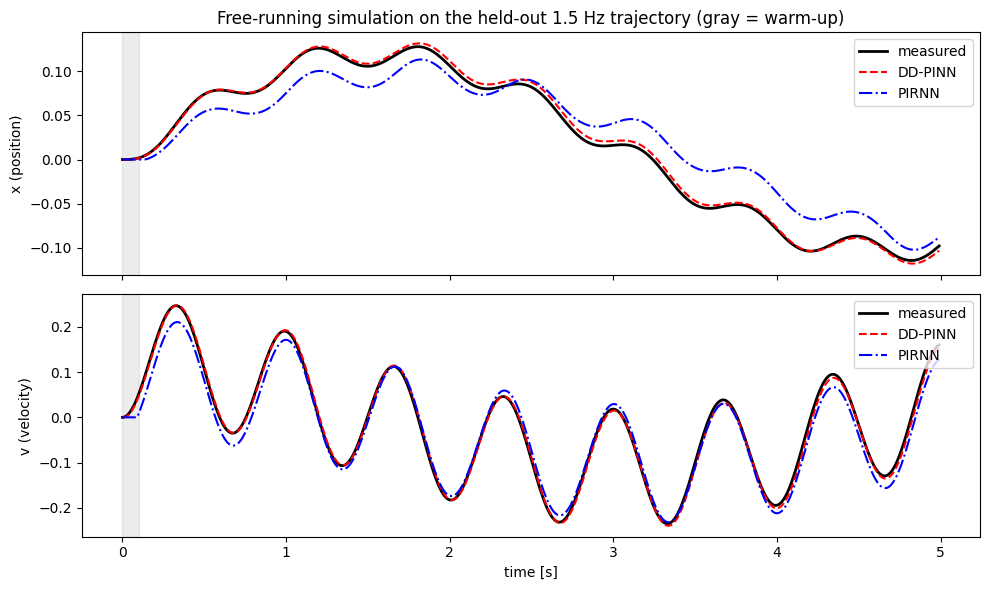

In [11]:
time = np.arange(N) * DT
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
for ax, j, name in zip(axes, (0, 1), ("x (position)", "v (velocity)")):
    meas = (x_test, v_test)[j]
    ax.plot(time, meas, "k-", lw=2, label="measured")
    ax.plot(time, ddpinn_pred[:, j], "r--", lw=1.5, label="DD-PINN")
    ax.plot(time, pirnn_pred[:, j], "b-.", lw=1.5, label="PIRNN")
    ax.axvspan(0, INIT_SZ * DT, color="gray", alpha=0.15)
    ax.set_ylabel(name)
    ax.legend(loc="upper right")
axes[-1].set_xlabel("time [s]")
axes[0].set_title("Free-running simulation on the held-out 1.5 Hz trajectory (gray = warm-up)")
fig.tight_layout()

## Takeaways

- Both models learn the same dynamics from the same equation with no fitting to the test
  trajectory — yet the **DD-PINN is markedly more accurate** here. Three structural
  reasons: its initial condition is exact (no soft anchor to balance), its physics
  residual uses the analytic `dx/dt` (no finite-difference error from `diff1_forward`),
  and it targets the continuous ODE directly rather than a discretized surrogate of it.
- The **PIRNN is the more flexible tool**: it ingests measured data through the same loss
  interface, learns an encoder from observation windows to state, and needs no closed-form
  ansatz — so it extends to systems where you only have an implicit residual or partial
  measurements.
- The **DD-PINN is the sharper instrument when you have an explicit ODE** and want a fast,
  IC-exact continuous-time simulator. The cost is that you must write the ODE as a
  first-order residual and supply physical ranges for the state and controls.
- Same physics, two encodings: a finite-difference loss on sampled RNN outputs, or a
  closed-form residual on a continuous ansatz. When the equations are known exactly, the
  structure baked into the DD-PINN ansatz pays off.